In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
x = torch.linspace(0,799,800)

In [5]:
π = np.pi

In [9]:
# Period of oscillation
T = 40

In [11]:
y = torch.sin(x*2*π/T)

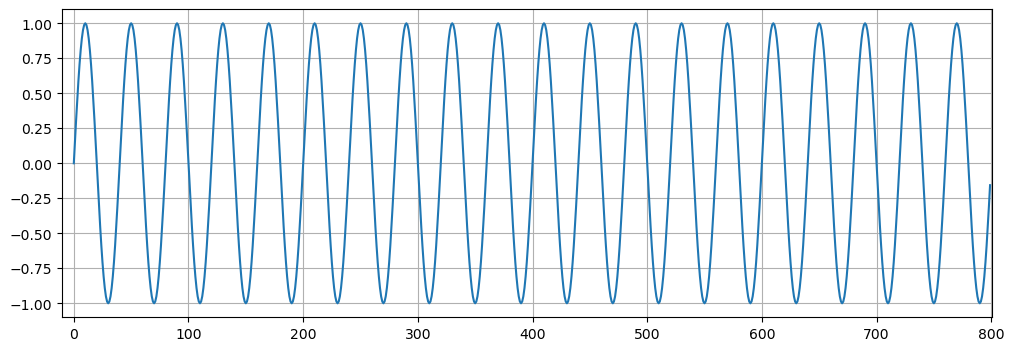

In [12]:
plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(y.numpy());

In [13]:
test_size = T
train_set = y[:-test_size]
test_set = y[-test_size:]

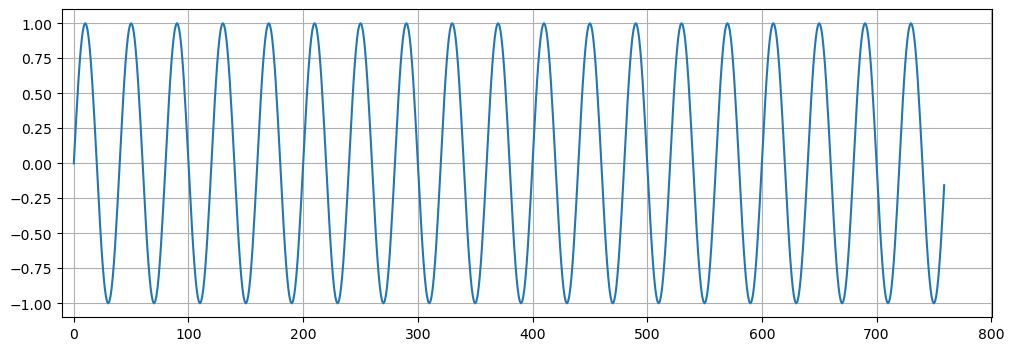

In [14]:
plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(train_set.numpy());

In [15]:
def input_data(seq,ws):
    
    out = []
    L = len(seq)
    
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    
    return out

In [16]:
window_size = T

train_data = input_data(train_set,window_size)

In [17]:
len(train_data)

720

In [18]:
train_data[0]

(tensor([ 0.0000e+00,  1.5643e-01,  3.0902e-01,  4.5399e-01,  5.8779e-01,
          7.0711e-01,  8.0902e-01,  8.9101e-01,  9.5106e-01,  9.8769e-01,
          1.0000e+00,  9.8769e-01,  9.5106e-01,  8.9101e-01,  8.0902e-01,
          7.0711e-01,  5.8779e-01,  4.5399e-01,  3.0902e-01,  1.5643e-01,
         -8.7423e-08, -1.5643e-01, -3.0902e-01, -4.5399e-01, -5.8779e-01,
         -7.0711e-01, -8.0902e-01, -8.9101e-01, -9.5106e-01, -9.8769e-01,
         -1.0000e+00, -9.8769e-01, -9.5106e-01, -8.9101e-01, -8.0902e-01,
         -7.0711e-01, -5.8779e-01, -4.5399e-01, -3.0902e-01, -1.5643e-01]),
 tensor([1.7485e-07]))

In [19]:
train_data[1]

(tensor([ 1.5643e-01,  3.0902e-01,  4.5399e-01,  5.8779e-01,  7.0711e-01,
          8.0902e-01,  8.9101e-01,  9.5106e-01,  9.8769e-01,  1.0000e+00,
          9.8769e-01,  9.5106e-01,  8.9101e-01,  8.0902e-01,  7.0711e-01,
          5.8779e-01,  4.5399e-01,  3.0902e-01,  1.5643e-01, -8.7423e-08,
         -1.5643e-01, -3.0902e-01, -4.5399e-01, -5.8779e-01, -7.0711e-01,
         -8.0902e-01, -8.9101e-01, -9.5106e-01, -9.8769e-01, -1.0000e+00,
         -9.8769e-01, -9.5106e-01, -8.9101e-01, -8.0902e-01, -7.0711e-01,
         -5.8779e-01, -4.5399e-01, -3.0902e-01, -1.5643e-01,  1.7485e-07]),
 tensor([0.1564]))

In [20]:
class LSTMmodel(nn.Module):
    
    def __init__(self, input_size=1, hidden_size=50, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.lstm = nn.LSTM(input_size,hidden_size)

        self.linear = nn.Linear(hidden_size,out_size)

        self.hidden = (torch.zeros(1,1,hidden_size),
                       torch.zeros(1,1,hidden_size))
    
    def forward(self,seq):
        lstm_out, self.hidden = self.lstm(
            seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]
        

In [21]:
model = LSTMmodel()

In [22]:
model

LSTMmodel(
  (lstm): LSTM(1, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [23]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [24]:
for p in model.parameters():
    print(p.numel())

200
10000
200
200
50
1


Epoch:  1 Loss: 0.07602109
Loss on test predictions: 0.5818660855293274


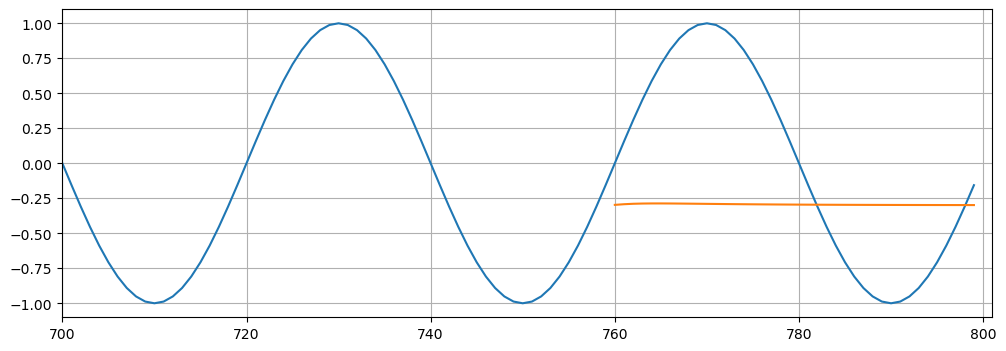

Epoch:  2 Loss: 0.03975717
Loss on test predictions: 0.5030707120895386


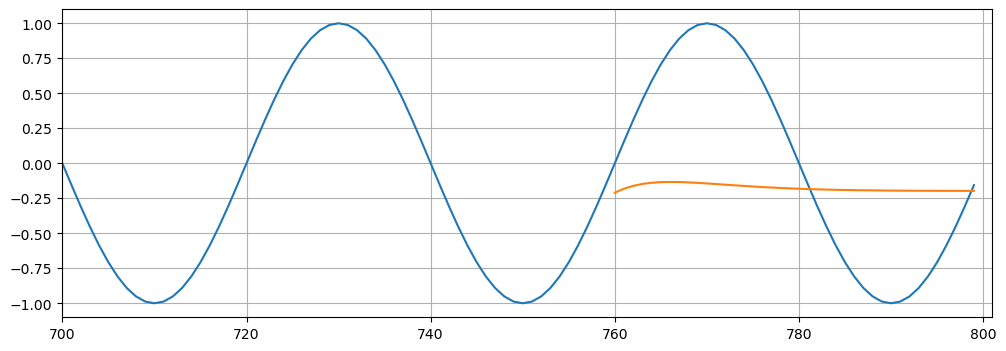

Epoch:  3 Loss: 0.00742823
Loss on test predictions: 0.2656388282775879


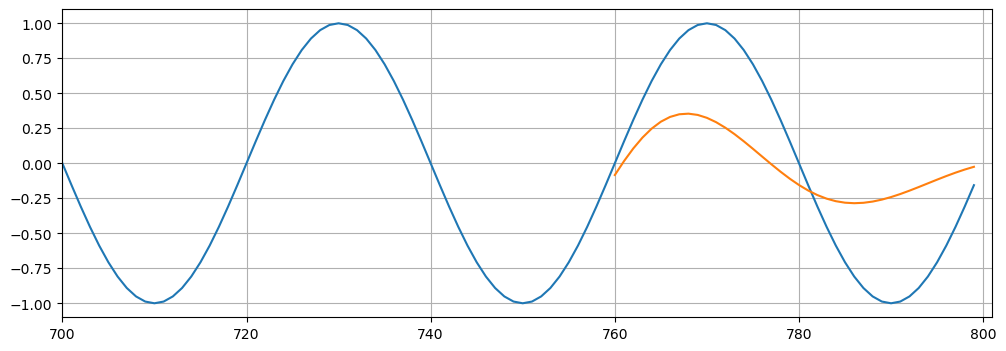

Epoch:  4 Loss: 0.00055147
Loss on test predictions: 0.015846475958824158


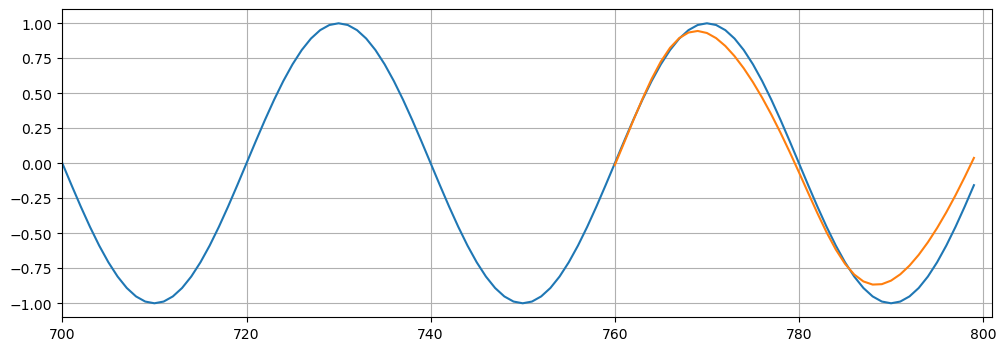

Epoch:  5 Loss: 0.00021844
Loss on test predictions: 0.0030746920965611935


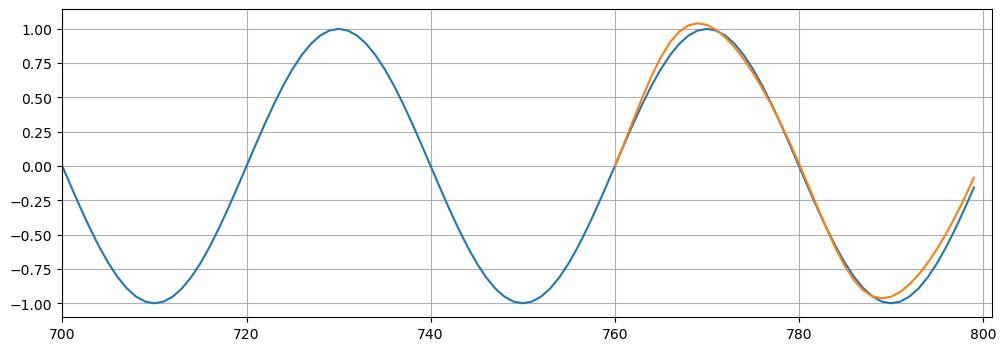

Epoch:  6 Loss: 0.00018003
Loss on test predictions: 0.0027164604980498552


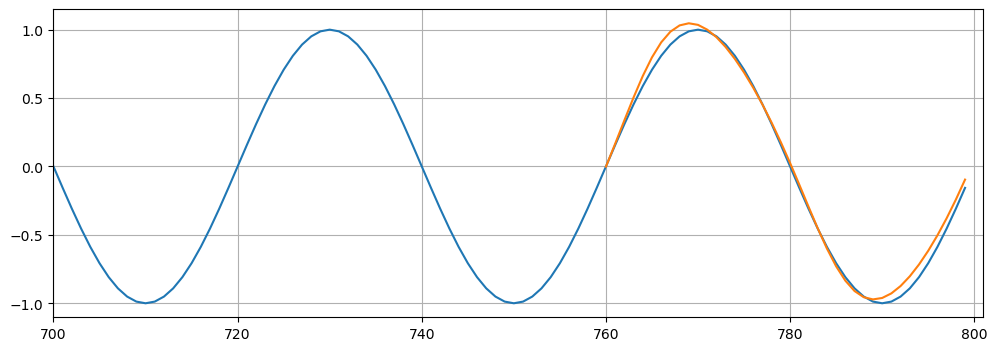

Epoch:  7 Loss: 0.00016123
Loss on test predictions: 0.002624961081892252


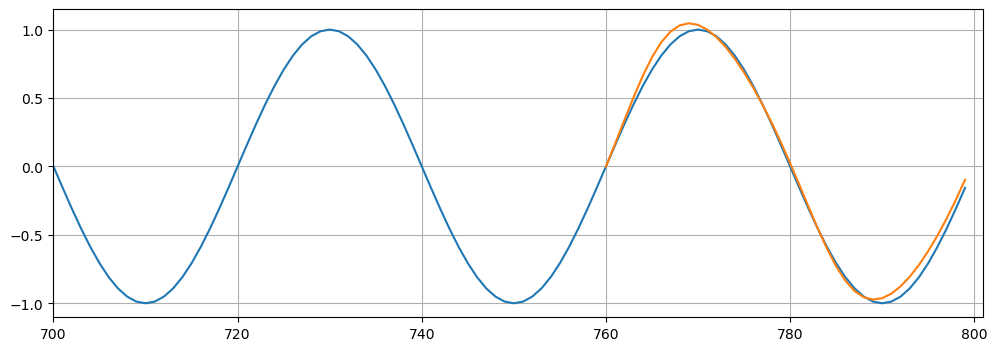

Epoch:  8 Loss: 0.00014643
Loss on test predictions: 0.002555639948695898


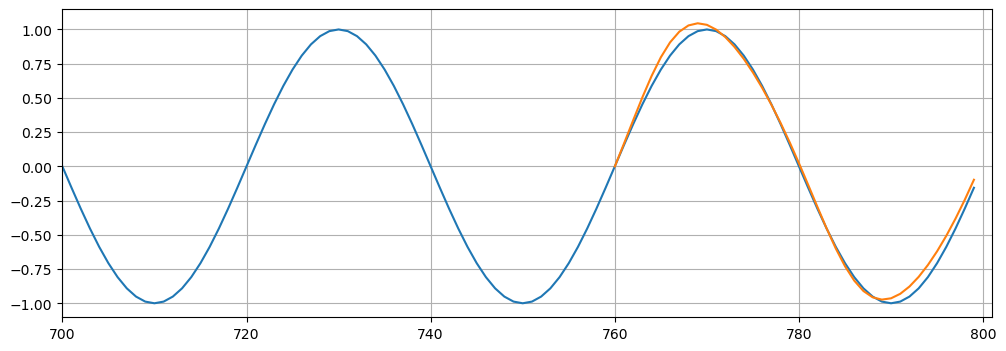

Epoch:  9 Loss: 0.00013404
Loss on test predictions: 0.002493476029485464


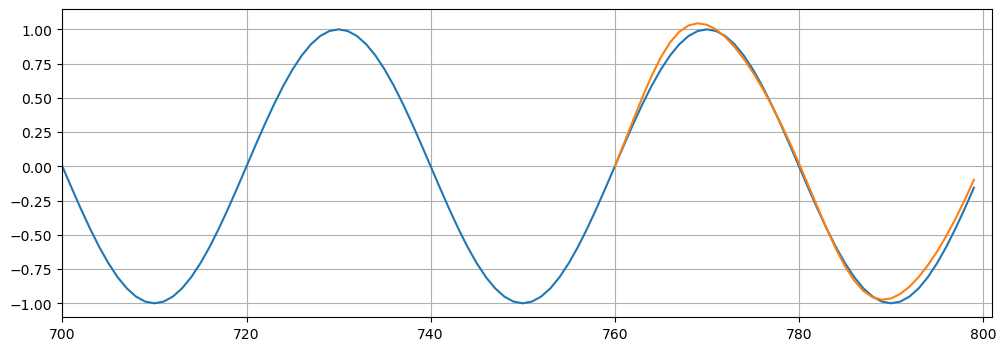

Epoch: 10 Loss: 0.00012350
Loss on test predictions: 0.002436137292534113


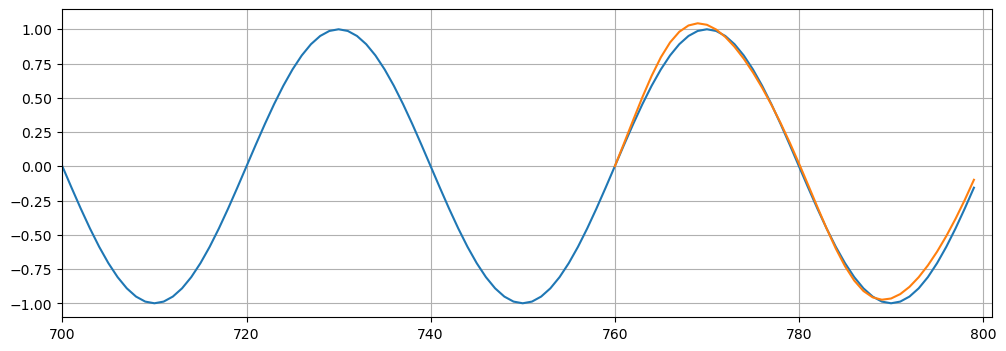

Epoch: 11 Loss: 0.00011444
Loss on test predictions: 0.002382537815719843


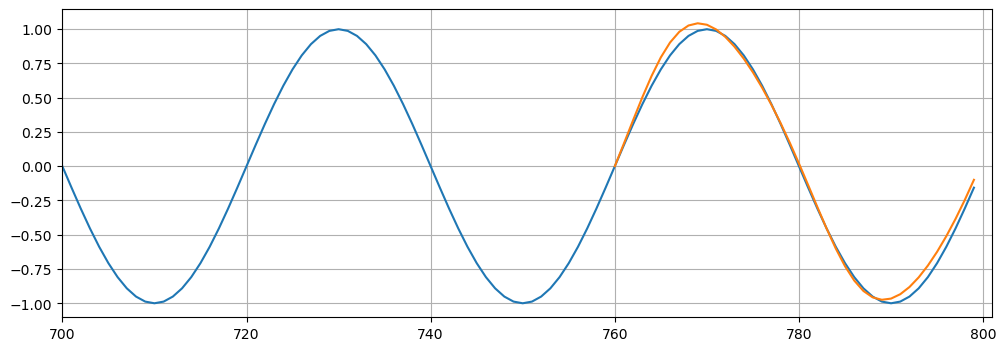

Epoch: 12 Loss: 0.00010657
Loss on test predictions: 0.0023318775929510593


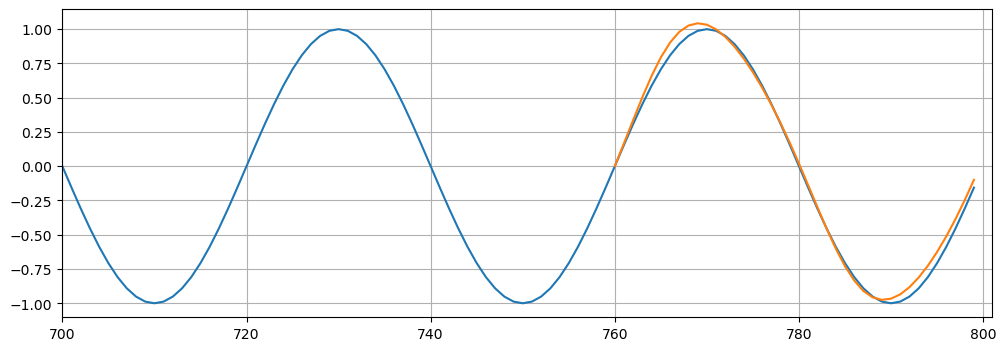

Epoch: 13 Loss: 0.00009969
Loss on test predictions: 0.0022837724536657333


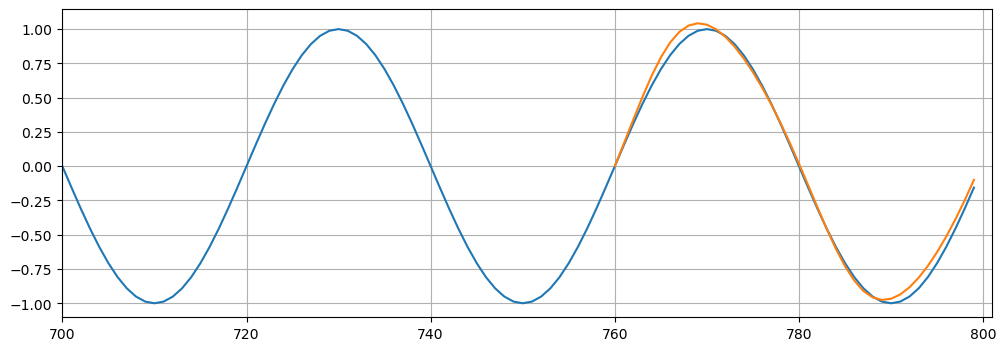

Epoch: 14 Loss: 0.00009361
Loss on test predictions: 0.0022377579007297754


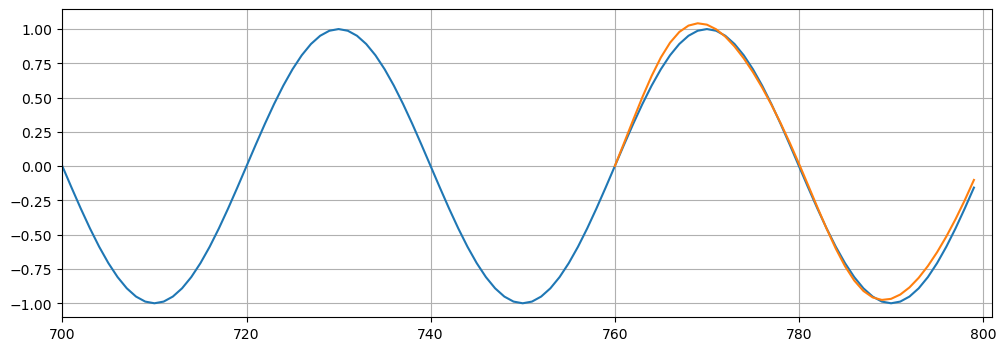

Epoch: 15 Loss: 0.00008821
Loss on test predictions: 0.002193476539105177


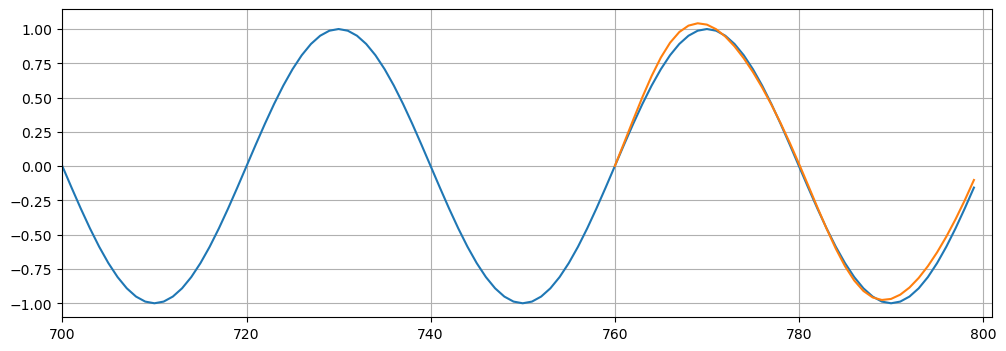

In [25]:
epochs = 15
future = T

for i in range(epochs):
    
    # tuple-unpack the train_data set
    for seq, y_train in train_data:
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')
    
    # MAKE PREDICTIONS
    # start with a list of the last 10 training records
    preds = train_set[-window_size:].tolist()

    for f in range(future):  
        seq = torch.FloatTensor(preds[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),
                            torch.zeros(1,1,model.hidden_size))
            preds.append(model(seq).item())
            
    loss = criterion(torch.tensor(preds[-window_size:]),y[760:])
    print(f'Loss on test predictions: {loss}')

    # Plot from point 700 to the end
    plt.figure(figsize=(12,4))
    plt.xlim(700,801)
    plt.grid(True)
    plt.plot(y.numpy())
    plt.plot(range(760,800),preds[window_size:])
    plt.show()

In [ ]:
epochs = 20
window_size = 40
future = 40

all_data = input_data(y,window_size)

In [ ]:
import time
start_time = time.time()

for i in range(epochs):
    
    # tuple-unpack the train_data set
    for seq, y_train in all_data:
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')
    
total_time = time.time() - start_time
print(total_time/60)

In [ ]:
preds = y[-window_size:].tolist()

for i in range(future):  
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        # Reset the hidden parameters
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))  
        preds.append(model(seq).item())

plt.figure(figsize=(12,4))
plt.xlim(-10,841)
plt.grid(True)
plt.plot(y.numpy())
plt.plot(range(800,800+future),preds[window_size:])
plt.show()